# Classification for severity

## Data Process

In [1]:
SEVERITY2ID = {
    "critical": 0,
    "high": 1,
    "medium": 2
}

ID2SEVERITY = {v: k for k, v in SEVERITY2ID.items()}
NUM_LABELS = 3

INSTRUCTION = (
    '''You are an expert enterprise support triage system.

    TASK:
    Classify the severity of the software issue based on the provided context.'''
)


In [2]:
def load_raw_data(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [3]:
import re
def clean_text(text,expertise):
    text = text.replace("intermittent failure", "glitch")
    text = text.replace("intermittent issue", "bug")
    text = text.replace("intermittent critical", "recurring")
    if expertise == "experienced":
        text = text.replace("critical", "serious")
        text = text.replace("impossible", "difficult")
        text = text.replace("outrageous", "frustrating")
        text = text.replace("unacceptable", "annoying")
        text = text.replace("infuriating", "upsetting")

    if expertise == "experienced":
        text = text.replace("panic", "concern")
    text = text.lower()

    text = re.sub(r'!+', '.', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [4]:
def build_severity_input_text(
    workflow_desc: str,
    components: list,
    complaint: str,
    industry: str,
    system: str,
    user_experience: str
) -> str:

    components_text = "\n".join(
        [f"- {c['name']}: {c['description']}" for c in components]
    )

    return (
        f"Instruction:\n{INSTRUCTION}\n\n"
        f"User Expertise Level: {user_experience.upper()}\n"
        f"Industry: {industry}\n"
        f"System: {system}\n\n"
        f"Workflow Context:\n{workflow_desc}\n\n"
        f"Affected Components:\n{components_text}\n\n"
        f"Complaint:\n{complaint}\n\n"
        f"Severity Prediction:"
    )

In [5]:
import json
from datasets import Dataset

def preprocess_severity_example(example):

    workflow = example["workflow"]

    workflow_desc = (
        f"{workflow['workflow_name']}. "
        f"{workflow['workflow_description']}"
    )

    user_experience = example["user_complaint"]["user_attributes"]["user_experience"]

    raw_complaint = example["user_complaint"]["user_complaint"]

    #complaint_text = clean_text(raw_complaint,user_experience)
    complaint_text = raw_complaint

    input_text = build_severity_input_text(
        workflow_desc=workflow_desc,
        components=workflow["workflow_components"],
        complaint=complaint_text,
        industry=example["industry"],
        system=example["system"],
        user_experience=user_experience
    )


    label = SEVERITY2ID[example["malfunction"]["severity"]]

    return {
        "input_text": input_text,
        "label": label,
        "example_id": example.get("example_id"),
        "workflow_name": workflow["workflow_name"]
    }


In [6]:
from datasets import Dataset
import json
def build_severity_dataset(raw_data):
    rows = [preprocess_severity_example(ex) for ex in raw_data]
    return Dataset.from_list(rows)


In [7]:
import torch
import numpy as np

def compute_class_weights(dataset):
    labels = dataset["label"]
    total = len(labels)

    count_0 = labels.count(0) # critical
    count_1 = labels.count(1) # high
    count_2 = labels.count(2) # medium

    print(f"DEBUG: Found counts -> Critical: {count_0}, High: {count_1}, Medium: {count_2}")


    w0 = total / (3 * max(count_0, 1)) *1.5
    w1 = (total / (3 * max(count_1, 1))) * 2
    w2 = (total / (3 * max(count_2, 1)))
    weights = np.sqrt([w0, w1, w2])


    weights = weights / np.mean(weights)

    print(f"Original Weights: {[w0, w1, w2]}")
    print(f"Softer Weights:   {weights}")

    return torch.tensor([w0, w1, w2], dtype=torch.float)

In [8]:
from sklearn.model_selection import train_test_split

def split_by_workflow(dataset, test_size=0.2, seed=42):
    workflows = list(set(dataset["workflow_name"]))

    train_wf, test_wf = train_test_split(
        workflows, test_size=test_size, random_state=seed
    )

    train_ds = dataset.filter(lambda x: x["workflow_name"] in train_wf)
    test_ds = dataset.filter(lambda x: x["workflow_name"] in test_wf)

    return train_ds, test_ds

In [9]:
with open("2190_dataset.json", "r") as f:
    raw_data = json.load(f)

## Tokenizer

In [10]:
from transformers import RobertaTokenizerFast

tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["input_text"],
        padding="max_length",
        truncation=True,
        max_length=384
    )

def tokenize_dataset(dataset):
    dataset = dataset.map(tokenize, batched=True)
    dataset = dataset.remove_columns(
        ["input_text", "workflow_name", "example_id"]
    )
    dataset.set_format("torch")
    return dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [11]:
def preprocess_pipeline(path):
    raw_data = load_raw_data(path)
    flat_ds = build_severity_dataset(raw_data)

    train_ds, test_ds = split_by_workflow(flat_ds)

    train_ds = tokenize_dataset(train_ds)
    test_ds = tokenize_dataset(test_ds)

    class_weights = compute_class_weights(train_ds)

    return train_ds, test_ds, class_weights

In [12]:
raw_data = load_raw_data("2190_dataset.json")
flat_ds = build_severity_dataset(raw_data)
train_ds, test_ds = split_by_workflow(flat_ds)
train_ds = tokenize_dataset(train_ds)
test_ds = tokenize_dataset(test_ds)

Filter:   0%|          | 0/2190 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2190 [00:00<?, ? examples/s]

Map:   0%|          | 0/1670 [00:00<?, ? examples/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

In [13]:
train_ds, test_ds, class_weights = preprocess_pipeline(
    "2190_dataset.json"
)

Filter:   0%|          | 0/2190 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2190 [00:00<?, ? examples/s]

Map:   0%|          | 0/1670 [00:00<?, ? examples/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

DEBUG: Found counts -> Critical: 559, High: 529, Medium: 582
Original Weights: [1.4937388193202148, 2.1045998739760554, 0.9564719358533792]
Softer Weights:   [1.00428782 1.19208063 0.80363155]


## Train

In [14]:
from transformers import Trainer
import torch
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [15]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }


In [16]:
!nvidia-smi

Tue Jan 13 10:36:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
import torch
print("PyTorch version:", torch.version)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: <module 'torch.version' from '/usr/local/lib/python3.12/dist-packages/torch/version.py'>
CUDA available: True
GPU name: Tesla T4


In [18]:
from transformers import TrainingArguments
from transformers import Trainer
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from transformers import EarlyStoppingCallback
import torch


model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)



for layer in model.roberta.encoder.layer[:4]: # מקפיא את שכבות 0 עד 5
    for param in layer.parameters():
        param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Moving model to: {device}")


model.to(device)

if isinstance(class_weights, torch.Tensor):
    class_weights = class_weights.to(device)

training_args = TrainingArguments(
    output_dir="./severity_roberta",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=10,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    label_smoothing_factor=0.0,
    metric_for_best_model="macro_f1",
    report_to="none",

    fp16=torch.cuda.is_available(),

)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    class_weights=class_weights,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


trainer.train()
trainer.evaluate()

trainer.save_model("./severity_model")
tokenizer.save_pretrained("./severity_model")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Moving model to: cuda


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.056700,1.103857,0.300000,0.153846
2,0.686900,0.689768,0.703846,0.696687
3,0.544100,0.613213,0.736538,0.732478
4,0.549700,0.593645,0.753846,0.745615
5,0.388900,0.607959,0.726923,0.729206
6,0.515100,0.617729,0.744231,0.734334


('./severity_model/tokenizer_config.json',
 './severity_model/special_tokens_map.json',
 './severity_model/vocab.json',
 './severity_model/merges.txt',
 './severity_model/added_tokens.json',
 './severity_model/tokenizer.json')

## Inference

In [19]:
from tqdm import tqdm
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from transformers import Trainer
import torch
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = "./severity_model"  #change name



tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_PATH)
model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(DEVICE)
model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [20]:
def predict_severity(example, max_length=384):
    """
    Predict severity label + probabilities for a single example
    """
    workflow = example["workflow"]

    workflow_desc = (
        f"{workflow['workflow_name']}. "
        f"{workflow['workflow_description']}"
    )

    # 1. Extract the text string, not the dictionary
    #raw_complaint = example["user_complaint"]["user_complaint"]
    # cleaning key words, so it would focus on technical matter
    #complaint_text = clean_text(raw_complaint)

    complaint_text = example["user_complaint"]["user_complaint"]

    # 2. Extract nested user experience
    user_experience = example["user_complaint"]["user_attributes"]["user_experience"]

    input_text = build_severity_input_text(
        workflow_desc=workflow_desc,
        components=workflow["workflow_components"],
        complaint=complaint_text,
        industry=example["industry"],
        system=example["system"],
        user_experience=user_experience
    )

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)[0]

    pred_id = probs.argmax().item()

    return {
        "predicted_severity": ID2SEVERITY[pred_id],
        "severity_scores": {
            ID2SEVERITY[i]: probs[i].item()
            for i in range(len(ID2SEVERITY))
        }
    }


In [21]:
def run_inference(test_path, output_path):
    with open(test_path, "r", encoding="utf-8") as f:
        test_data = json.load(f)

    results = []

    for example in tqdm(test_data, desc="Running severity inference"):
        prediction = predict_severity(example)

        output = {
            "example_id": example.get("example_id"),
            **prediction,

            "ground_truth_severity": example["malfunction"]["severity"]
        }


        if "severity" in example:
            output["ground_truth_severity"] = example["severity"]

        results.append(output)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    print(f"Inference results saved to: {output_path}")


## Evaluation

In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,f1_score
import matplotlib.pyplot as plt

def evaluate_predictions(results_path):
    print(f"--- Loading results from: {results_path} ---")

    with open(results_path, "r", encoding="utf-8") as f:
        results = json.load(f)

    y_true = []
    y_pred = []

    for item in results:
        if "ground_truth_severity" not in item:
            continue

        y_true.append(item["ground_truth_severity"])
        y_pred.append(item["predicted_severity"])

    if not y_true:
        print("No ground truth severity labels found.")
        return

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 40)
    print("      SEVERITY EVALUATION      ")
    print("=" * 40)
    print(f"Total Examples:        {len(y_true)}")
    print(f"Accuracy:              {acc:.2%}")
    print("-" * 40)
    print(f"Precision (weighted):  {precision:.4f}")
    print(f"Recall (weighted):     {recall:.4f}")
    print(f"F1-score (weighted):   {f1:.4f}")
    print(f"F1 Score (macro):     {f1_macro:.4f}")
    print("=" * 40)

    print("\nDetailed classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("\n")
    print("\n")
    print("\n")
    cm = confusion_matrix(y_true, y_pred, labels=["critical", "high", "medium"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["critical", "high", "medium"])
    disp.plot(cmap="Blues")
    plt.show()


In [23]:
run_inference(
    test_path="test_easy.json",
    output_path="severity_predictions_easy.json")

Running severity inference: 100%|██████████| 200/200 [00:04<00:00, 44.85it/s]

Inference results saved to: severity_predictions_easy.json


--- Loading results from: severity_predictions_easy.json ---

      SEVERITY EVALUATION      
Total Examples:        200
Accuracy:              79.00%
----------------------------------------
Precision (weighted):  0.7918
Recall (weighted):     0.7900
F1-score (weighted):   0.7905
F1 Score (macro):     0.7783

Detailed classification report:
              precision    recall  f1-score   support

    critical       0.68      0.72      0.70        61
        high       0.70      0.67      0.68        63
      medium       0.96      0.95      0.95        76

    accuracy                           0.79       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.79      0.79      0.79       200









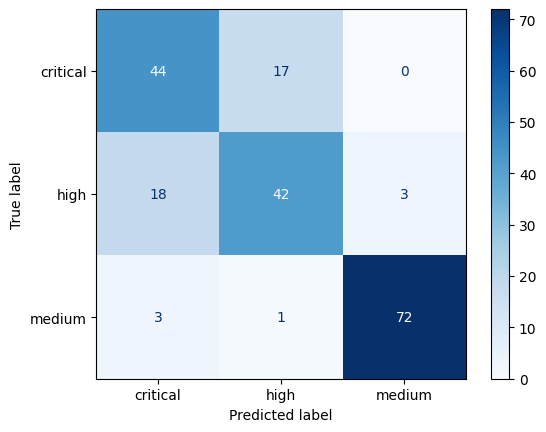

In [24]:
evaluate_predictions("severity_predictions_easy.json")

In [25]:
run_inference(
    test_path="test_hard.json",
    output_path="severity_predictions_hard.json"
)

Running severity inference: 100%|██████████| 200/200 [00:04<00:00, 46.61it/s]

Inference results saved to: severity_predictions_hard.json


--- Loading results from: severity_predictions_hard.json ---

      SEVERITY EVALUATION      
Total Examples:        200
Accuracy:              75.50%
----------------------------------------
Precision (weighted):  0.7547
Recall (weighted):     0.7550
F1-score (weighted):   0.7443
F1 Score (macro):     0.7303

Detailed classification report:
              precision    recall  f1-score   support

    critical       0.66      0.85      0.74        75
        high       0.61      0.40      0.48        57
      medium       0.98      0.94      0.96        68

    accuracy                           0.76       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.75      0.76      0.74       200









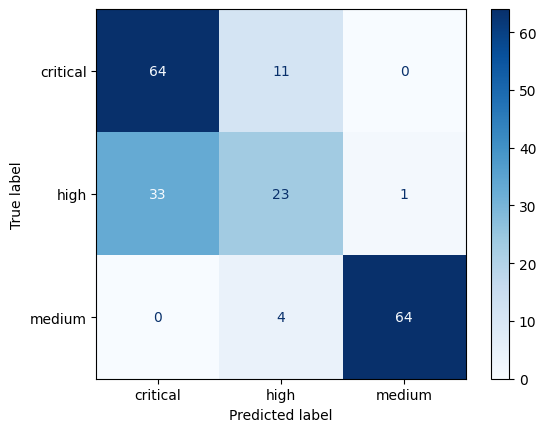

In [26]:
evaluate_predictions("severity_predictions_hard.json")

In [27]:
import json
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

def analyze_model_failures(pred_file, truth_file):
    # 1. Load the files
    print(f"Loading {pred_file} and {truth_file}...")
    with open(pred_file, 'r', encoding='utf-8') as f:
        preds = json.load(f)
    with open(truth_file, 'r', encoding='utf-8') as f:
        truth_data = json.load(f)

    # 2. Convert to DataFrames
    df_pred = pd.DataFrame(preds)
    df_truth = pd.DataFrame(truth_data)

    # 3. Merge on example_id to ensure we compare the right items
    #    We rename columns to avoid confusion
    df_merged = pd.merge(df_pred, df_truth, on='example_id', suffixes=('_pred', '_truth'))

    # Handle cases where column names might differ in the truth file
    # (Adjust 'malfunction' -> 'severity' path if needed based on your file structure)
    if 'severity' not in df_merged.columns:
        # Try to extract severity from nested malfunction object if it exists
        df_merged['ground_truth_severity'] = df_merged['malfunction'].apply(lambda x: x.get('severity'))

    # 4. Filter for Failures
    #    We compare the 'predicted_severity' with 'ground_truth_severity'
    df_failed = df_merged[df_merged['predicted_severity'] != df_merged['ground_truth_severity']].copy()

    print("\n" + "="*50)
    print(f"Overall Accuracy: {1 - (len(df_failed) / len(df_merged)):.2%}")
    print(f"Total Errors: {len(df_failed)} out of {len(df_merged)}")
    print("="*50)

    # 5. Generate Confusion Matrix
    labels = ['medium', 'high', 'critical']
    cm = confusion_matrix(df_merged['ground_truth_severity'], df_merged['predicted_severity'], labels=labels)

    print("\n--- Confusion Matrix (Rows=Truth, Cols=Prediction) ---")
    cm_df = pd.DataFrame(cm, index=[f"True {l}" for l in labels], columns=[f"Pred {l}" for l in labels])
    print(cm_df)

    # 6. Deep Dive into Top Error Patterns
    print("\n" + "="*50)
    print("   TOP FAILED EXAMPLES (READ THESE TO UNDERSTAND WHY)")
    print("="*50)

    # We iterate through the specific error types
    for true_label in labels:
        for pred_label in labels:
            if true_label == pred_label: continue

            # Find errors of this specific type (e.g., True: Medium -> Pred: High)
            specific_errors = df_failed[
                (df_failed['ground_truth_severity'] == true_label) &
                (df_failed['predicted_severity'] == pred_label)
            ]

            if len(specific_errors) > 0:
                print(f"\n⚠️  PATTERN: Real is '{true_label.upper()}', but Model predicted '{pred_label.upper()}'")
                print(f"    Count: {len(specific_errors)}")

                # Print 2 examples
                for i, row in specific_errors.head(4).iterrows():
                    print("-" * 20)
                    print(f"ID: {row['example_id']}")
                    # Extract complaint text safely
                    complaint = row.get('user_complaint', {}).get('user_complaint', "N/A")
                    print(f"Complaint: \"{complaint[:200]}...\"")  # Show first 200 chars
                    print(f"Model Confidence for '{pred_label}': {row['severity_scores'].get(pred_label, 0):.4f}")

# Run the function
analyze_model_failures('severity_predictions.json', 'test_hard_v2.json')

Loading severity_predictions.json and test_hard_v2.json...


FileNotFoundError: [Errno 2] No such file or directory: 'severity_predictions.json'

In [ ]:
run_inference(
    test_path="2190_dataset.json",
    output_path="severity_predictions_2190.json"
)

In [ ]:
evaluate_predictions("severity_predictions_2190.json")

In [ ]:
def predict_severity(example, max_length=384, critical_threshold=0.5):
    """
    Predict severity with a confidence threshold to reduce false alarms.
    critical_threshold: Probability required to label as 'critical' (default 0.5)
    """
    workflow = example["workflow"]

    workflow_desc = (
        f"{workflow['workflow_name']}. "
        f"{workflow['workflow_description']}"
    )

    complaint_text = example["user_complaint"]["user_complaint"]
    user_experience = example["user_complaint"]["user_attributes"]["user_experience"]

    input_text = build_severity_input_text(
        workflow_desc=workflow_desc,
        components=workflow["workflow_components"],
        complaint=complaint_text,
        industry=example["industry"],
        system=example["system"],
        user_experience=user_experience
    )

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        # Get raw probabilities (0.0 to 1.0)
        probs = F.softmax(outputs.logits, dim=-1)[0]

    # --- START OF NEW THRESHOLD LOGIC ---

    # 1. Get individual probabilities
    # Assuming mapping: 0=Critical, 1=High, 2=Medium
    prob_critical = probs[0].item()
    prob_high     = probs[1].item()
    prob_medium   = probs[2].item()

    # 2. Apply "Safety Logic"
    # Only say CRITICAL if the model is VERY sure (score > threshold)
    if prob_critical >= critical_threshold:
        pred_id = 0  # Critical
    else:
        # If not surely Critical, pick the winner between High and Medium
        if prob_high >= prob_medium:
            pred_id = 1  # High
        else:
            pred_id = 2  # Medium

    # --- END OF NEW THRESHOLD LOGIC ---

    return {
        "predicted_severity": ID2SEVERITY[pred_id],
        "severity_scores": {
            ID2SEVERITY[i]: probs[i].item()
            for i in range(len(ID2SEVERITY))
        }
    }

In [ ]:
run_inference(
    test_path="test_hard_updated.json",
    output_path="severity_predictions_test.json"
)

In [ ]:
evaluate_predictions("severity_predictions_test.json")